In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, yaml, os

import tensorflow as tf
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from msfm.fiducial_pipeline import FiducialPipeline
from msfm.utils import files, parameters, logger

from deep_lss.models.delta_model import DeltaLossModel
from deep_lss.nets import resnet
from deep_lss.utils import configuration

LOGGER = logger.get_logger("temp")

24-02-29 05:04:06   imports.py INF   Setting up healpy to run on 32 CPUs 
24-02-29 05:04:06   imports.py INF   Setting up healpy to run on 32 CPUs 


In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")

# training loss = -50.356048583984375
# validation loss = -43.50503921508789
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"
model_dir = os.path.join(base_dir, "delta/2024-01-12_19-35-59_resnet_vanilla")

# training loss = -50.67667007446289
# validation loss = 24.448930740356445
# base_dir = "/pscratch/sd/a/athomsen/run_files/v7/lensing"
# model_dir = os.path.join(base_dir, "delta/2024-02-22_03-37-44_resnet_vanilla")

params = ["Om", "s8", "w0", "Aia", "n_Aia"]
perts = parameters.get_fiducial_perturbations(params, conf)

with open(os.path.join(model_dir, "configs.yaml"), "r") as f:
    net_conf, dlss_conf, msfm_conf = list(yaml.load_all(f, Loader=yaml.FullLoader))

In [4]:
version = "v7"
bias = "linear_bias"

fidu_pipe = FiducialPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=False,
    with_padding=True,
    apply_norm=True,
)

n_side = 512
data_vec_pix = fidu_pipe.data_vec_pix
n_z_bins = 4
n_params= len(params)
local_batch_size = 16

train_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/DESy3_fiducial_????.tfrecord"
train_dset = fidu_pipe.get_dset(
    tfr_pattern=train_pattern,
    local_batch_size=local_batch_size,
    n_noise=3,
    n_readers=1,
    is_eval=True,
    n_prefetch=1,
)

vali_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/validation/DESy3_fiducial_????.tfrecord"
vali_dset = fidu_pipe.get_dset(
    tfr_pattern=vali_pattern,
    local_batch_size=local_batch_size,
    n_noise=3,
    n_readers=1,
    is_eval=True,
    n_prefetch=1,
)


24-02-29 05:04:08     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-02-29 05:04:09     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-02-29 05:04:11 fiducial_pip WAR   Evaluation mode is activated: the random seed is fixed, the shuffle arguments ignored, and the dataset is not repeated 
24-02-29 05:04:11 fiducial_pip INF   Interleaving with n_readers = 1 


/global/common/software/des/athomsen/dlss/lib/python3.9/site-packages/tensorflow/python/data/ops/dataset_ops.py:2210: UserWarning: The `deterministic` argument has no effect unless the `num_parallel_calls` argument is specified.
  warnings.warn("The `deterministic` argument has no effect unless the "


24-02-29 05:04:12 fiducial_pip INF   Batching into 16 elements locally 
24-02-29 05:04:12 fiducial_pip WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
24-02-29 05:04:13 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'kg_delta_Om_m', 'kg_delt

In [5]:
smoothing_kwargs = configuration.get_smoothing_kwargs(
    "delta", msfm_conf, dlss_conf, net_conf, dir_base=base_dir
)

network = resnet.ResNetLayers(
    out_dim=n_params, smoothing_kwargs=smoothing_kwargs, **net_conf["network"]["kwargs"]
).get_layers()

model = DeltaLossModel(
    network=network,
    n_side=n_side,
    indices=data_vec_pix,
    n_neighbors=net_conf["network"]["n_neighbors"],
    checkpoint_dir=os.path.join(model_dir, "checkpoint"),
    max_batch_size=(2*n_params+1)*local_batch_size,
    input_shape=(None, len(data_vec_pix), n_z_bins),
    restore_checkpoint=True,
    strategy=None,
)

model.setup_delta_loss_step(
    n_params,
    local_batch_size,
    perts,
    n_channels=n_z_bins,
    **dlss_conf["delta_loss"],
    **net_conf["optimization"]["gradient_clipping"],
)

24-02-29 05:04:14     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-02-29 05:04:14     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
Using the per channel smoothing repetitions [6 3 2 1]
Using the per channel smoothing scales sigma = [9.78 6.91 5.65 3.99] arcmin, fwhm = [23.03 16.28 13.29  9.4 ] arcmin
Successfully loaded sparse kernel indices and values from /pscratch/sd/a/athomsen/run_files/v6/lensing_only/smoothing
Successfully created the sparse kernel tensor
24-02-29 05:04:15 base_model.p INF   Initializing with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Successfully built the smoothing layer
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 2 splits

In [6]:
@tf.function
def loss_fn(batch):
    preds = model(batch)
    loss = model.loss_fn(preds)
    return loss    

In [7]:
losses = []
for batch, _ in LOGGER.progressbar(train_dset):
    losses.append(loss_fn(batch))
    
losses = tf.stack(losses, axis=0)
losses = tf.reduce_mean(losses)
print(f"training loss = {losses}")


  0%|                            |   | 0/? [00:00<?, ?it/s]                   24-02-29 05:04:22 delta_loss.p WAR   Tracing delta_loss 
  0%|                            |   | 135/? [04:06<00:00,  1.83s/it]         
training loss = -50.35392761230469


In [8]:
losses = []
for batch, _ in LOGGER.progressbar(vali_dset):
    losses.append(loss_fn(batch))
    
losses = tf.stack(losses, axis=0)
losses = tf.reduce_mean(losses)
print(f"validation loss = {losses}")


  0%|                            |   | 15/? [00:29<00:00,  1.97s/it]          
validation loss = -43.493614196777344


# histograms

In [9]:
version = "v7"
bias = "linear_bias"

fidu_pipe_hist = FiducialPipeline(
    conf=conf,
    params=[],
    with_lensing=True,
    with_clustering=False,
    with_padding=True,
    apply_norm=True,
)

n_side = 512
data_vec_pix = fidu_pipe.data_vec_pix
n_z_bins = 4
n_params= len(params)
local_batch_size = 32

train_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/DESy3_fiducial_????.tfrecord"
train_dset_hist = fidu_pipe_hist.get_dset(
    tfr_pattern=train_pattern,
    local_batch_size=local_batch_size,
    n_noise=3,
    n_readers=1,
    is_eval=True,
    n_prefetch=1,
)

vali_pattern = f"/pscratch/sd/a/athomsen/DESY3/{version}/{bias}/tfrecords/fiducial/validation/DESy3_fiducial_????.tfrecord"
vali_dset_hist = fidu_pipe_hist.get_dset(
    tfr_pattern=vali_pattern,
    local_batch_size=local_batch_size,
    n_noise=3,
    n_readers=1,
    is_eval=True,
    n_prefetch=1,
)


24-02-29 05:08:54     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-02-29 05:08:54     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
24-02-29 05:08:54 fiducial_pip WAR   Evaluation mode is activated: the random seed is fixed, the shuffle arguments ignored, and the dataset is not repeated 
24-02-29 05:08:54 fiducial_pip INF   Interleaving with n_readers = 1 
24-02-29 05:08:54 fiducial_pip INF   Batching into 32 elements locally 
24-02-29 05:08:54 fiducial_pip WAR   Tracing _augmentations 
24-02-29 05:08:54 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'i_example', 'sn', 'i_noise']) 
24-02-29 05:08:54 fiducial_pip WAR   Tracing _lensing_augmentations 
24-02-29 05:08:54 fiducial_pip INF   Prefetching 1 elements 
24-02-29 05:08:54 fiducial_pip INF   Successfully generated the fiducial training set with e

In [10]:
train_preds = []
for batch, _ in LOGGER.progressbar(train_dset_hist):
    train_preds.append(model.tf_call(batch))
    
train_preds = tf.concat(train_preds, axis=0)
train_preds = train_preds.numpy()

  0%|                            |   | 0/? [00:00<?, ?it/s]                   24-02-29 05:08:57 base_model.p WAR   Tracing tf_call 
  0%|                            |   | 67/? [03:14<00:00,  2.84s/it]          24-02-29 05:12:09 base_model.p WAR   Tracing tf_call 
  0%|                            |   | 68/? [03:15<00:00,  2.88s/it]          


In [11]:
vali_preds = []
for batch, _ in LOGGER.progressbar(vali_dset_hist):
    vali_preds.append(model.tf_call(batch))
    
vali_preds = tf.concat(vali_preds, axis=0)
vali_preds = vali_preds.numpy()

  0%|                            |   | 8/? [00:21<00:00,  2.70s/it]           


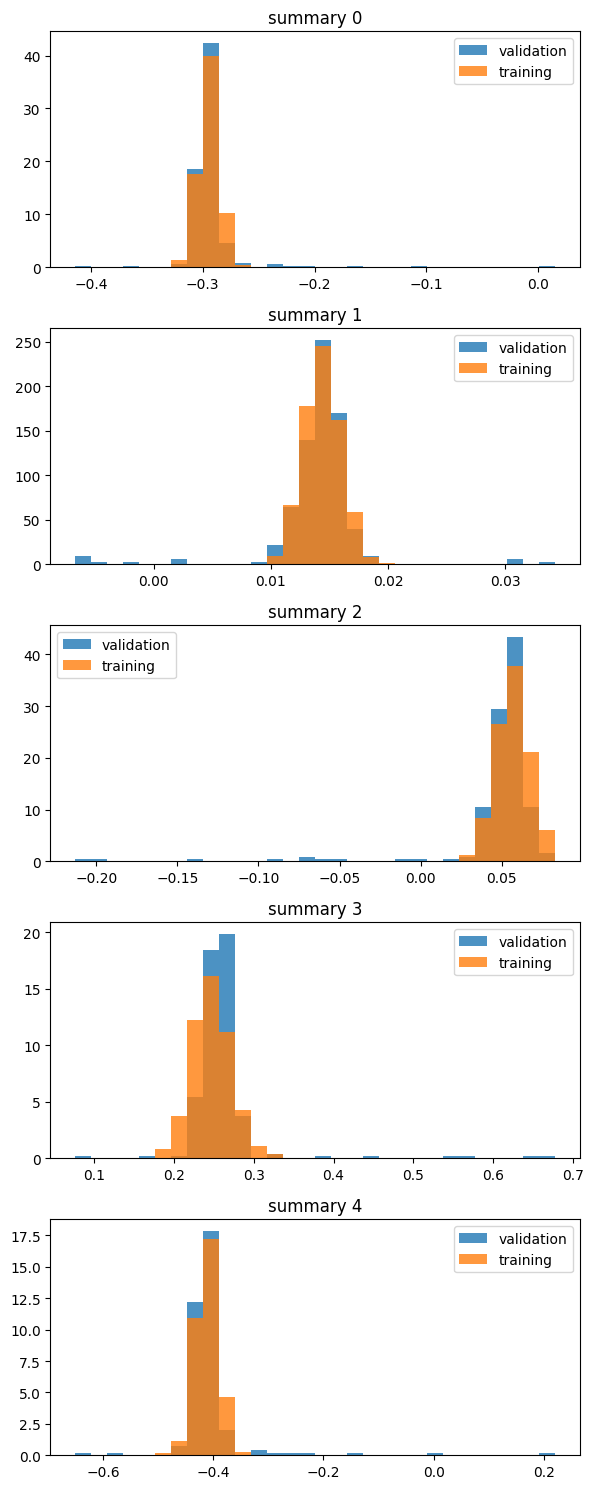

In [12]:
n_summaries = vali_preds.shape[1]

fig, ax = plt.subplots(nrows=n_summaries, figsize=(6, 3*n_summaries))

for i in range(n_summaries):
    _, bins, _ = ax[i].hist(vali_preds[:,i], bins=30, label="validation", density=True, alpha=0.8)
    _ = ax[i].hist(train_preds[:,i], bins=bins, label="training", density=True, alpha=0.8)

    ax[i].set(title=f"summary {i}")
    ax[i].legend()
    
plt.tight_layout()